### Evaluator Optimizer

In the evaluator-optimizer workflow, one LLM call generates a response while another provides evaluation and feedback in a loop.

When to use this workflow: This workflow is particularly effective when we have clear evaluation criteria, and when iterative refinement provides measurable values. The two signs of good fit are, first that LLM responses can be demonstrably improved when a human articulates their feedback, and second that the LLM can provide such feedback.

This is analogous to the iterative writing process a human writer might go through when producing a polished document.

Usecase:

Generate a joke and get it evaluated with feedback for improvization.

In [47]:
#importing libraries

import os
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END


load_dotenv()


True

In [48]:
#base model

model = init_chat_model(model="groq:llama-3.1-8b-instant")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002BD07CF4890>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002BD06BC5730>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [49]:
#defining schema

class State(BaseModel):
    topic: str = Field(description="the topic to generate joke on")
    grade: str = Field(description="grades the joke generated")
    output: str = Field(description="joke to display to user")

In [50]:
#defining nodes to generate jok and evaluate it

def generator(state:State):
    "this function generates output based on user query"
    if state.grade != "" and "feedback" in state.grade.lower():
        feedback_prompt = f"""Generate joke on the topic, but also take into account on the following feedback.
                            Topic: {state.topic}
                            Feebback: {state.grade}"""
        response = model.invoke(feedback_prompt)
    else:
         gen_prompt = f"Generate a joke in funny way for the topic given by the user.\n Topic: {state.topic} "
         response = model.invoke(gen_prompt)    
    return {"output": response.content}

def evaluator(state:State):
    "this function evaluates the output generated by model and provides feedback"
    eval_prompt =f"""You are a joke evaluator, for the given topic evalute whether provided response is funny or not.
                    Answer only by saying 'yes' or 'no' if it's a no, provide proper feedback on how you reached that conclusion
                    Topic: {state.topic}
                    Generated Response: {state.output}"""
    response = model.invoke(eval_prompt)

    if "no" in response.content.lower():
        return {"grade": f"FAIL & FEEDBACK: {response.content}"} 
    else:
        return {"grade": f"PASS: {response.content}"}



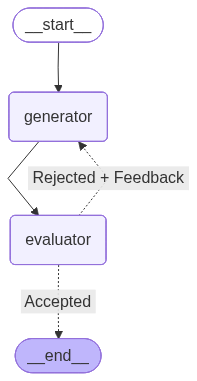

In [51]:
#defining graph workflow

graph_builder = StateGraph(State)

graph_builder.add_node("generator", generator)
graph_builder.add_node("evaluator", evaluator)

graph_builder.add_edge(START, "generator")
graph_builder.add_edge("generator", "evaluator")
graph_builder.add_conditional_edges("evaluator", lambda s : "Accepted" if "yes" in s.grade.lower() else "Rejected + Feedback",
                                    {"Rejected + Feedback": "generator", "Accepted":END} )

graph = graph_builder.compile()
graph

In [52]:
#graph invocation
query="dentist"
state = State(topic=query, grade="", output="")
result = graph.invoke(state)
result



{'topic': 'dentist',
 'grade': 'PASS: yes',
 'output': 'Here\'s one:\n\nA man walked into a dentist\'s office and said, "Doc, I\'ve been having a lot of trouble with my teeth. I\'ve been feeling a little \'drilled\' into a corner."\n\nThe dentist replied, "Don\'t worry, we\'ll \'fill\' you in on the details later."\n\n(ba-dum-tss)\n\nHow was that?'}

In [ ]:
#generated and evaluted joke

print(f"JOKE on {result['topic']}:\n {result['output']}")

JOKE on dentist:
 Here's one:

A man walked into a dentist's office and said, "Doc, I've been having a lot of trouble with my teeth. I've been feeling a little 'drilled' into a corner."

The dentist replied, "Don't worry, we'll 'fill' you in on the details later."

(ba-dum-tss)

How was that?
